# Principal Component Analysis with Cancer Data

In [2]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [3]:
# import data set
df = pd.read_csv( 'cancer.csv' )
df.head(10)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


In [4]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done

In [5]:
# drop ID column as it is useless for the model
if 'ID' in df.columns:
    df.drop(['ID'], axis=1, inplace = True)

# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [6]:
# print datatype pf each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null object
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: int64(9), object(1)
memory usage: 54.7+ KB


In [7]:
# Shape of database
df.shape

(699, 10)

In [8]:
# study the Data Distribution for each attribute
df.describe().T


,count,mean,std,min,25%,50%,75%,max
ClumpThickness,699.0,4.417740,2.815741,1.0,2.0,4.0,6.0,10.0
Cell Size,699.0,3.134478,3.051459,1.0,1.0,1.0,5.0,10.0
Cell Shape,699.0,3.207439,2.971913,1.0,1.0,1.0,5.0,10.0
Marginal Adhesion,699.0,2.806867,2.855379,1.0,1.0,1.0,4.0,10.0
Single Epithelial Cell Size,699.0,3.216023,2.214300,1.0,2.0,2.0,4.0,10.0
Normal Nucleoli,699.0,3.437768,2.438364,1.0,2.0,3.0,5.0,10.0
Bland Chromatin,699.0,2.866953,3.053634,1.0,1.0,1.0,4.0,10.0
Mitoses,699.0,1.589413,1.715078,1.0,1.0,1.0,1.0,10.0
Class,699.0,2.689557,0.951273,2.0,2.0,2.0,4.0,4.0


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000001DFEE918C18>,
      dtype=object)

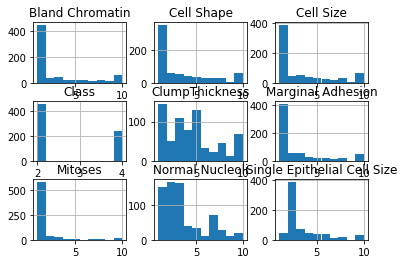

In [9]:
# Plot the distribution of variables using histogram
df.hist()


# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [10]:
# We could see "?" values in column, this should be removed from data set

# Check for missing value in any other column

In [11]:
# check how many missing values
df.isnull().sum()

ClumpThickness                 0
Cell Size                      0
Cell Shape                     0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Normal Nucleoli                0
Bland Chromatin                0
Mitoses                        0
Class                          0
dtype: int64

In [12]:
# No missing values found. So let us try to remove ? from bare nuclei column

# Get count of rows having ?


In [13]:
# check for non-numeric values
temp = pd.DataFrame(df['Bare Nuclei'].str.isdigit())  
temp[temp['Bare Nuclei'] == False].count() 

Bare Nuclei    16
dtype: int64

In [14]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values

In [15]:
# check for non-numeric values
df = df.replace('?', np.nan)
df = df.apply(lambda x: x.fillna(x.median()),axis=0)

In [16]:
# converting the column from object 'Bare Nuclei' string type to float
df['Bare Nuclei'] = df['Bare Nuclei'].astype('float64')  
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null float64
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: float64(1), int64(9)
memory usage: 54.7 KB


# Q4. Perform bi variate analysis including correlation & pairplots. 


In [17]:
# Check for correlation of variable

In [18]:
df.corr()

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
ClumpThickness,1.000000,0.644913,0.654589,0.486356,0.521816,0.590008,0.558428,0.535835,0.350034,0.716001
Cell Size,0.644913,1.000000,0.906882,0.705582,0.751799,0.686673,0.755721,0.722865,0.458693,0.817904
Cell Shape,0.654589,0.906882,1.000000,0.683079,0.719668,0.707474,0.735948,0.719446,0.438911,0.818934
Marginal Adhesion,0.486356,0.705582,0.683079,1.000000,0.599599,0.666971,0.666715,0.603352,0.417633,0.696800
Single Epithelial Cell Size,0.521816,0.751799,0.719668,0.599599,1.000000,0.583701,0.616102,0.628881,0.479101,0.682785
Bare Nuclei,0.590008,0.686673,0.707474,0.666971,0.583701,1.000000,0.674215,0.574778,0.342397,0.818968
Normal Nucleoli,0.558428,0.755721,0.735948,0.666715,0.616102,0.674215,1.000000,0.665878,0.344169,0.756616
Bland Chromatin,0.535835,0.722865,0.719446,0.603352,0.628881,0.574778,0.665878,1.000000,0.428336,0.712244
Mitoses,0.350034,0.458693,0.438911,0.417633,0.479101,0.342397,0.344169,0.428336,1.000000,0.423170
Class,0.716001,0.817904,0.818934,0.696800,0.682785,0.818968,0.756616,0.712244,0.423170,1.000000


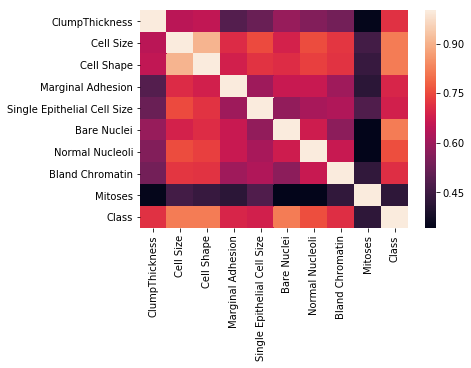

In [19]:
sns.heatmap(df.corr())

In [20]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

In [21]:
#Let us check for pair plots

C:\Users\Suchi\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval
C:\Users\Suchi\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
C:\Users\Suchi\Anaconda3\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2
C:\Users\Suchi\Anaconda3\lib\site-packages\numpy\core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


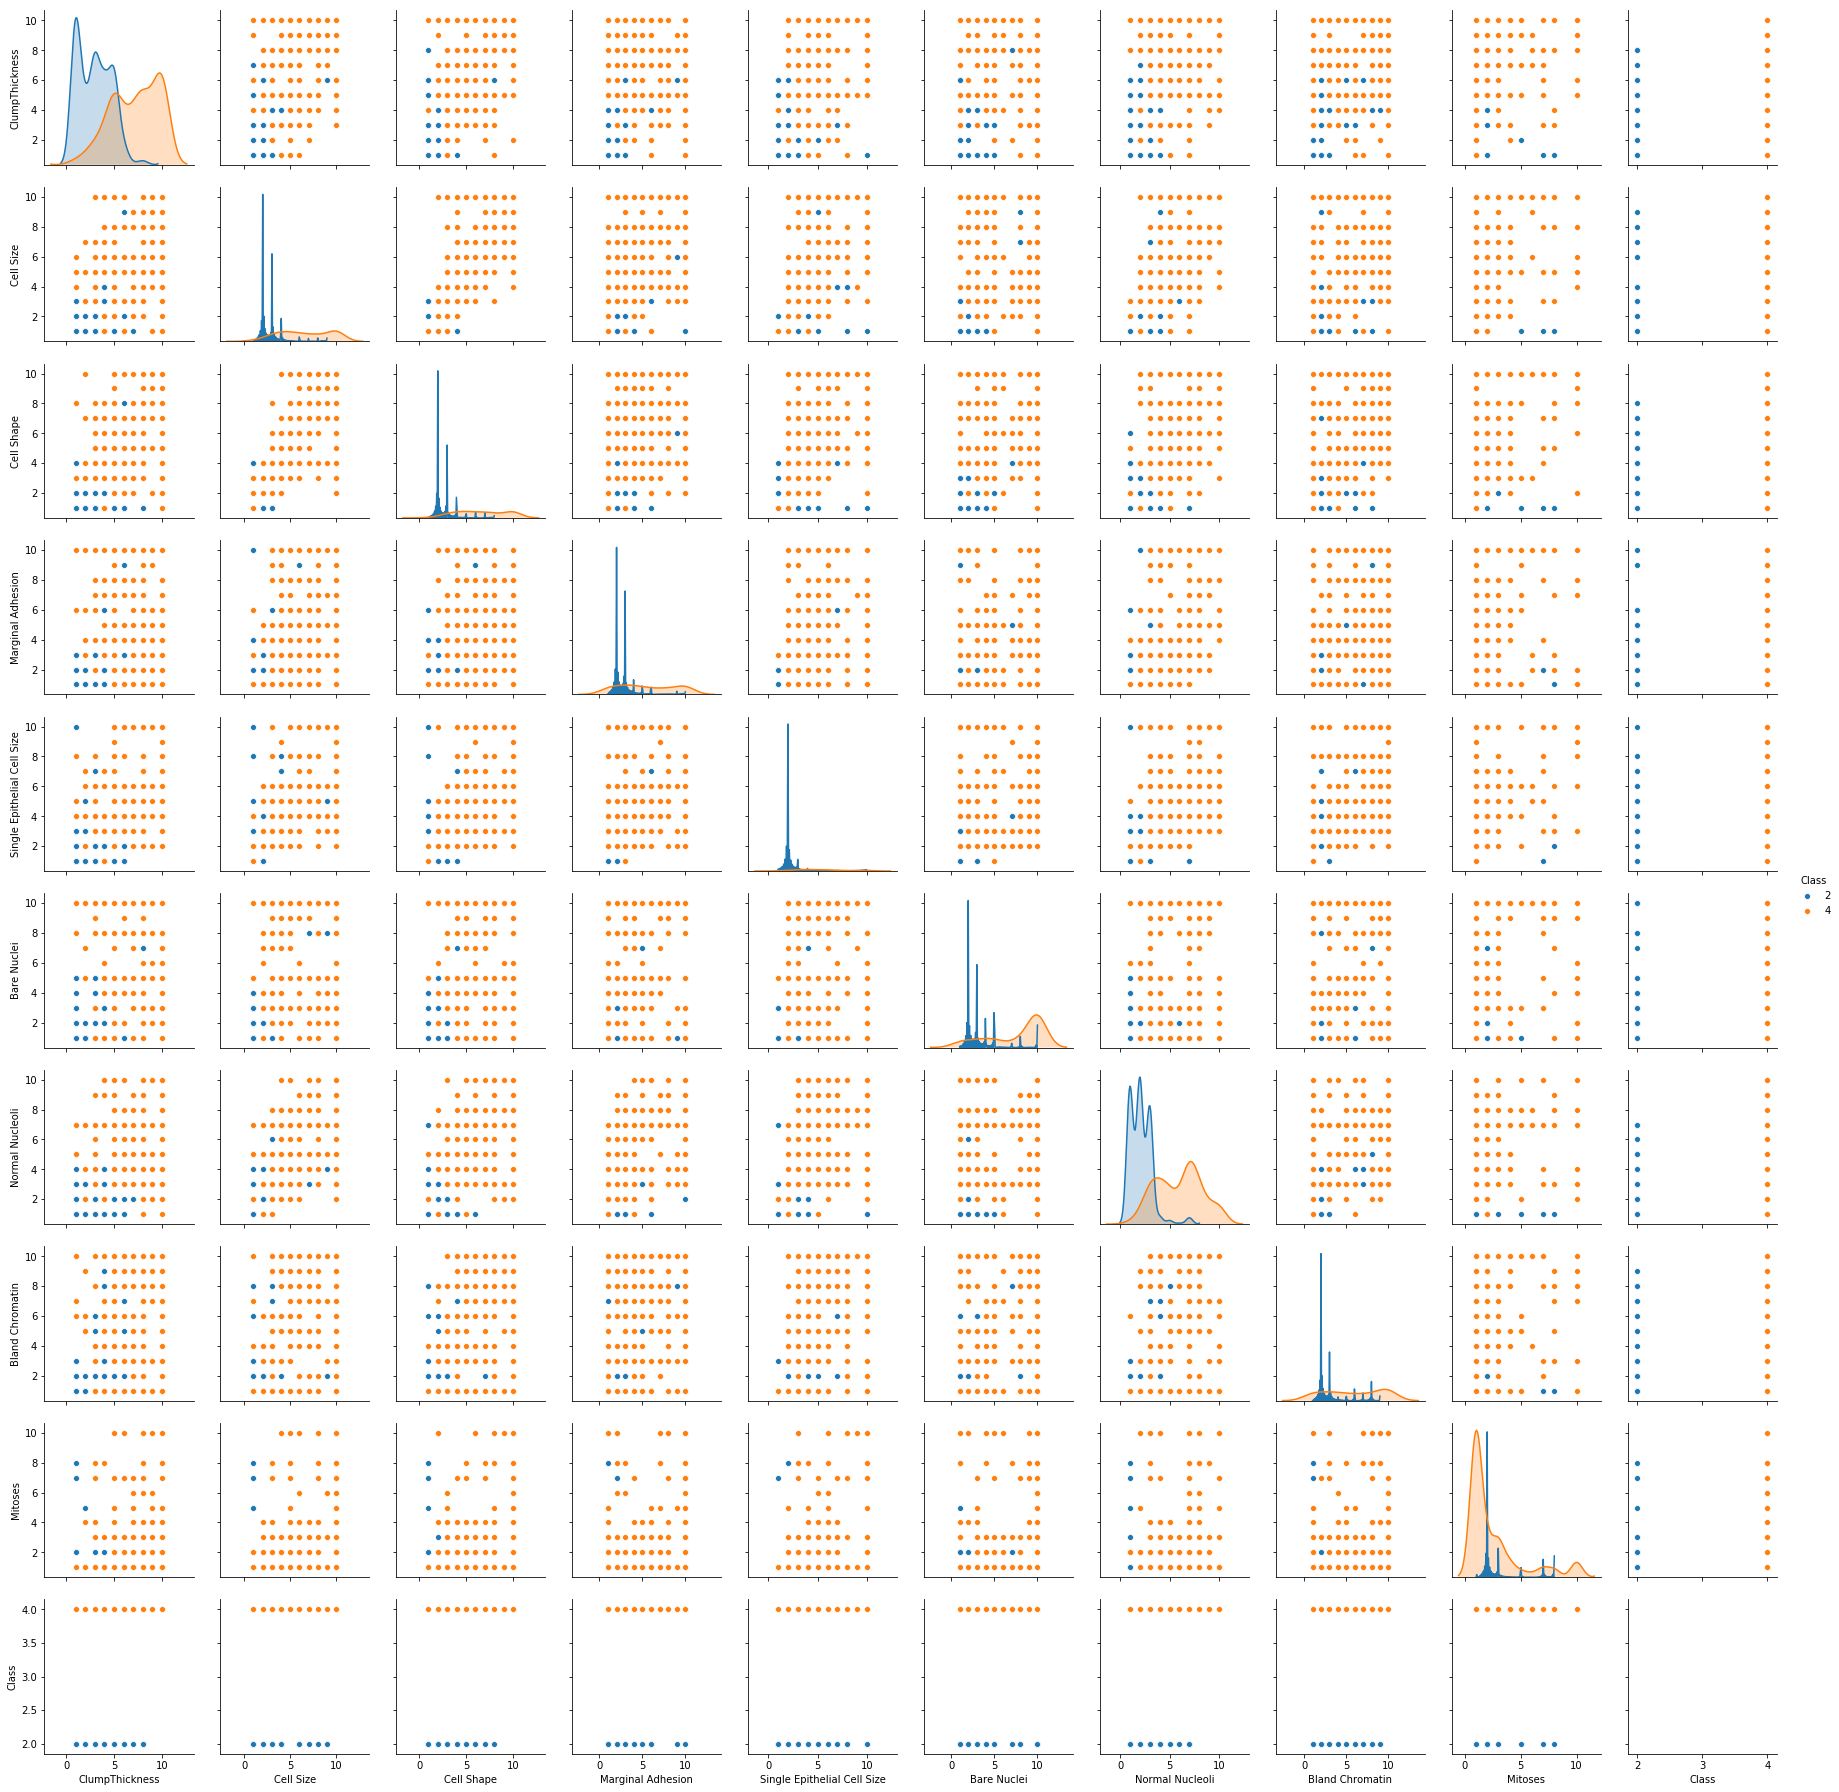

In [22]:
# Pairplot using sns
sns.pairplot(df,hue="Class",diag_kind="kde")

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

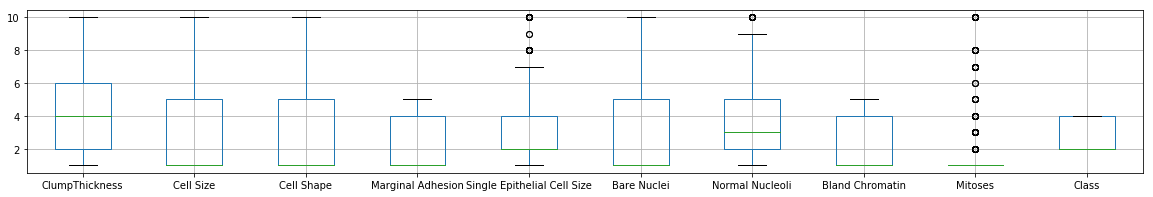

In [33]:
# check for outliers
df.boxplot(figsize=(20, 3))

In [34]:
# We could see outliers in few of the columns
# check if we need to remove any value

In [35]:
df['Class'].value_counts()

2    458
4    241
Name: Class, dtype: int64

In [36]:
pd.crosstab(df['Marginal Adhesion'],df['Class'])

Class,2,4
Marginal Adhesion,,
1,375,32
2,37,21
3,31,27
4,5,28
5,10,133


In [53]:
df['Marginal Adhesion'] = np.where(df['Marginal Adhesion'] > 5,5,df['Marginal Adhesion'] )

In [54]:
pd.crosstab(df['Single Epithelial Cell Size'],df['Class'])

Class,2,4
Single Epithelial Cell Size,,
1,46,1
2,363,23
3,29,43
4,7,41
5,13,133


In [55]:
df['Single Epithelial Cell Size'] = np.where(df['Single Epithelial Cell Size'] > 5,5,df['Single Epithelial Cell Size'] )

In [56]:
pd.crosstab(df['Bland Chromatin'],df['Class'])

Class,2,4
Bland Chromatin,,
1,402,41
2,30,6
3,12,32
4,1,17
5,13,145


In [57]:
df['Bland Chromatin'] = np.where(df['Bland Chromatin'] > 5,5,df['Bland Chromatin'] )

In [58]:
pd.crosstab(df['Normal Nucleoli'],df['Class'])

Class,2,4
Normal Nucleoli,,
1,150,2
2,159,7
3,129,36
4,8,32
5,12,164


In [59]:
df['Normal Nucleoli'] = np.where(df['Normal Nucleoli'] > 5,5,df['Normal Nucleoli'] )

In [60]:
pd.crosstab(df['Mitoses'],df['Class'])

Class,2,4
Mitoses,,
1,445,134
2,8,27
3,2,31
4,3,49


In [61]:
df['Mitoses'] = np.where(df['Mitoses'] > 4,4,df['Mitoses'] )

In [62]:
# Prepare X and Y
X = df.drop("Class", axis=1)
y = df["Class"]

In [63]:
# standardize variables

from scipy.stats import zscore
# apply z_score
X_std = X.apply(zscore) 

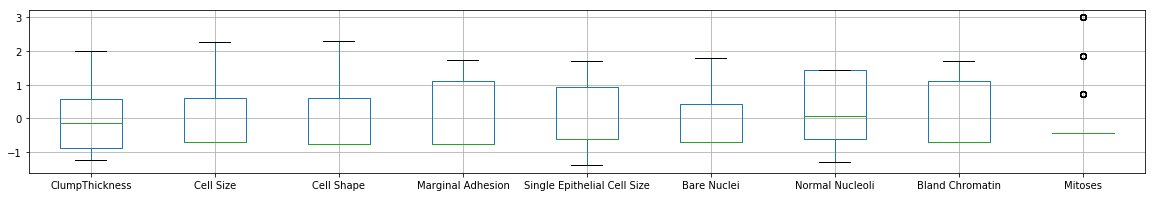

In [64]:
X_std.boxplot(figsize=(20, 3))

In [65]:
# We could see most of the outliers are now removed.

# Q6 Create a covariance matrix for identifying Principal components

In [66]:
# PCA
# Step 1 - Create covariance matrix


In [75]:
X_std.shape

(699, 9)

In [76]:
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[1.00143266 0.64583645 0.65552689 0.5412577  0.5759771  0.5908535
  0.57367417 0.56679455 0.40800705]
 [0.64583645 1.00143266 0.90818117 0.72835309 0.78893865 0.68765657
  0.71445936 0.73114712 0.50781935]
 [0.65552689 0.90818117 1.00143266 0.70884596 0.76479818 0.70848734
  0.70097947 0.72305564 0.47875736]
 [0.5412577  0.72835309 0.70884596 1.00143266 0.69551948 0.7003226
  0.65818904 0.66502316 0.4335433 ]
 [0.5759771  0.78893865 0.76479818 0.69551948 1.00143266 0.67329762
  0.67022089 0.72186739 0.48127168]
 [0.5908535  0.68765657 0.70848734 0.7003226  0.67329762 1.00143266
  0.69013785 0.63439548 0.43528712]
 [0.57367417 0.71445936 0.70097947 0.65818904 0.67022089 0.69013785
  1.00143266 0.67912177 0.39435748]
 [0.56679455 0.73114712 0.72305564 0.66502316 0.72186739 0.63439548
  0.67912177 1.00143266 0.4765211 ]
 [0.40800705 0.50781935 0.47875736 0.4335433  0.48127168 0.43528712
  0.39435748 0.4765211  1.00143266]]


# Q7 Identify eigen values and eigen vector

In [77]:
# Step 2- Get eigen values and eigen vector

In [78]:
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)

In [79]:
print('Eigen Vectors \n%s', eig_vecs)
print('\n Eigen Values \n%s', eig_vals)

Eigen Vectors 
%s [[-0.30247134 -0.03401489  0.01194865  0.9090712  -0.03383873 -0.13385659
  -0.0654883  -0.23964217 -0.00459654]
 [-0.37024664 -0.03797298  0.72906945 -0.01620222  0.35768201  0.20055631
  -0.13197341  0.31712931  0.20862277]
 [-0.36701765 -0.0789292  -0.67111006  0.03817855  0.32748064  0.35220363
  -0.03469626  0.34787653  0.2317521 ]
 [-0.33726467 -0.12640602 -0.05069549 -0.29493946 -0.28219402 -0.07635275
  -0.53679707 -0.45708573  0.44516634]
 [-0.35092467 -0.02818301 -0.06755611 -0.19472942  0.29596572 -0.76029966
   0.39637958 -0.02251482  0.10148524]
 [-0.33600762 -0.13875791  0.08744115 -0.03423495 -0.64645355  0.23487708
   0.5911121   0.11389477  0.15353229]
 [-0.33462336 -0.22688811 -0.04230942 -0.08775853 -0.27958446 -0.21133241
  -0.37269235  0.3912276  -0.64208244]
 [-0.34046826 -0.00759716  0.0180416  -0.1915387   0.2804787   0.36594681
   0.19605073 -0.58275835 -0.5063423 ]
 [-0.24297824  0.95058338 -0.03210686 -0.03741593 -0.14733573 -0.01345998
  -0

# Q8 Find variance and cumulative variance by each eigen vector

In [80]:
eigen_pairs = [(np.abs(eig_vals[i]), eig_vecs[ :, i]) for i in range(len(eig_vals))]

In [81]:
tot = sum(eig_vals)
var_exp = [( i /tot ) * 100 for i in sorted(eig_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
print("Cumulative Variance Explained", cum_var_exp)

Cumulative Variance Explained [ 67.85755873  75.5509827   81.14986911  85.73072424  89.68569392
  93.1444508   96.24227195  99.01222147 100.        ]


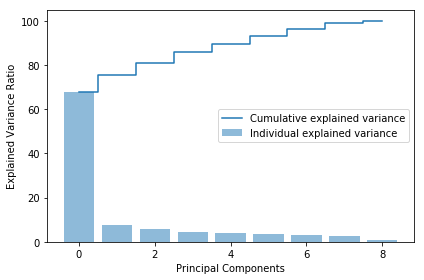

In [82]:
plt.figure(figsize=(6 , 4))
plt.bar(range(9), var_exp, alpha = 0.5, align = 'center', label = 'Individual explained variance')
plt.step(range(9), cum_var_exp, where='mid', label = 'Cumulative explained variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.legend(loc = 'best')
plt.tight_layout()
plt.show()

In [83]:
# First four principal components explain more than 80% of the variance in the data. 

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [84]:
from sklearn.decomposition import PCA

pca = PCA(n_components=9)

pca.fit(X_std)

PCA(copy=True, iterated_power='auto', n_components=9, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)

In [85]:
# transform based on the principal components
X_pca = pca.transform(X_std)
X_pca.shape

(699, 9)

In [86]:
pca.components_
pca.explained_variance_

array([6.11592983, 0.69340015, 0.5046217 , 0.41286762, 0.35645722,
       0.31173409, 0.27920334, 0.24965261, 0.08902743])

In [87]:
pca.explained_variance_ratio_

array([0.67857559, 0.07693424, 0.05598886, 0.04580855, 0.0395497 ,
       0.03458757, 0.03097821, 0.0276995 , 0.00987779])

# Q10 Find correlation between components and features

In [88]:
type(X_pca)

numpy.ndarray

In [89]:
pca_df = pd.DataFrame(X_pca)  # converting array to dataframe for pairplot

In [90]:
pca_df.corr()

,0,1,2,3,4,5,6,7,8
0,1.000000e+00,3.888475e-15,4.273489e-16,1.307258e-16,-1.745697e-16,-6.069594e-16,-6.558293e-16,3.478090e-16,1.281916e-15
1,3.888475e-15,1.000000e+00,7.152560e-17,2.211721e-16,8.782163e-17,6.322264e-16,2.313569e-17,6.038296e-16,5.030201e-16
2,4.273489e-16,7.152560e-17,1.000000e+00,-1.432215e-16,-1.924851e-16,2.424242e-16,2.707774e-16,-5.565772e-16,3.316899e-16
3,1.307258e-16,2.211721e-16,-1.432215e-16,1.000000e+00,-1.143303e-16,-1.484150e-16,-3.340247e-16,-6.553286e-16,-3.847436e-16
4,-1.745697e-16,8.782163e-17,-1.924851e-16,-1.143303e-16,1.000000e+00,5.316693e-16,5.195637e-16,1.293222e-15,-3.690630e-16
5,-6.069594e-16,6.322264e-16,2.424242e-16,-1.484150e-16,5.316693e-16,1.000000e+00,1.157805e-16,3.473825e-15,1.894630e-18
6,-6.558293e-16,2.313569e-17,2.707774e-16,-3.340247e-16,5.195637e-16,1.157805e-16,1.000000e+00,5.542609e-16,-4.918842e-16
7,3.478090e-16,6.038296e-16,-5.565772e-16,-6.553286e-16,1.293222e-15,3.473825e-15,5.542609e-16,1.000000e+00,-4.397640e-16
8,1.281916e-15,5.030201e-16,3.316899e-16,-3.847436e-16,-3.690630e-16,1.894630e-18,-4.918842e-16,-4.397640e-16,1.000000e+00


In [ ]:
# pca reduces the corelation between the features significantly

C:\Users\Suchi\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


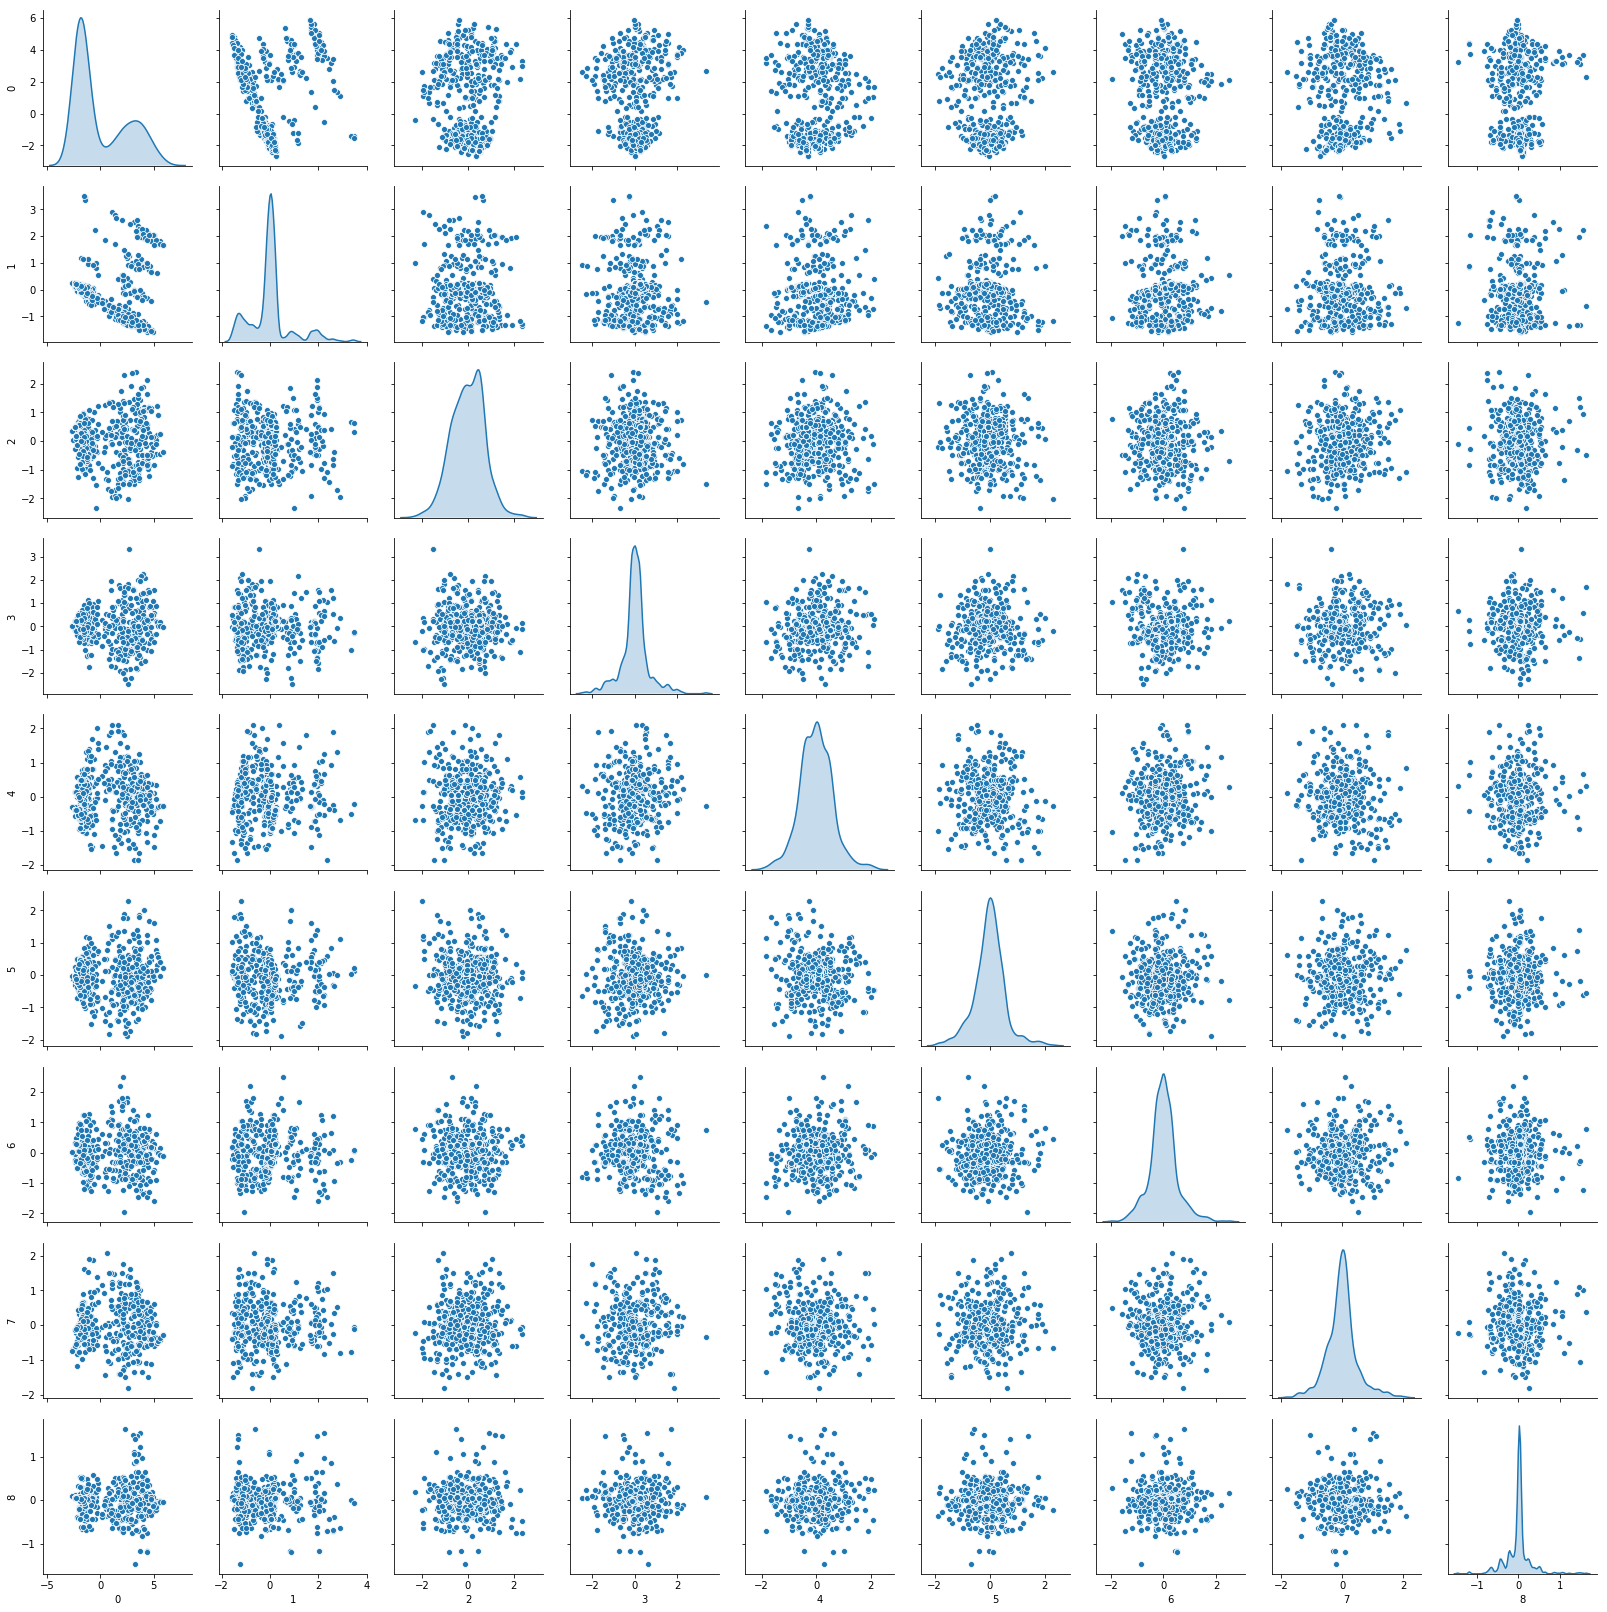

In [91]:
sns.pairplot(pca_df,diag_kind="kde")